# Prediccion de Precios de Vivienda con Red Neuronal

Este notebook replica el proceso de carga, limpieza y preparacion de datos del analisis principal, y sustituye el modelo SVM por una red neuronal basica con una sola capa oculta para la prediccion de precios de viviendas en la CDMX.


## 1. Importacion de Librerias


In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modelos y metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Reducir warnings numericos esperables durante la optimizacion
warnings.filterwarnings('ignore')

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

# Crear carpeta de visualizaciones
visualizations_dir = Path('visualizations')
visualizations_dir.mkdir(exist_ok=True)

print('Librerias importadas correctamente')


Librerias importadas correctamente


## 2. Carga del Dataset


In [2]:
# Cargar el archivo CSV
csv_path = Path('housing_data_CDMX_v2.csv')
df = pd.read_csv(csv_path)

# Informacion basica
print(f'Archivo cargado: {csv_path}')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'\nTipos de datos:')
print(df.info())


Archivo cargado: housing_data_CDMX_v2.csv
Filas: 18234
Columnas: 13

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  object 
 1   places                      18234 non-null  object 
 2   lat-lon                     18234 non-null  object 
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  object 
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
 11  lat                         18234 non-null  float64
 12  lon

## 3. Limpieza y Preparacion de Datos


In [3]:
# Eliminacion de columnas innecesarias
columns_to_drop = [
    'currency',
    'price_aprox_usd',
    'price_usd_per_m2',
    'lat-lon',
    'price_aprox_local_currency',
    'places'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print('Columnas despues de eliminar innecesarias:')
print(list(df.columns))


Columnas despues de eliminar innecesarias:
['property_type', 'price', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_per_m2', 'lat', 'lon']


In [4]:
# Eliminacion de outliers usando el metodo del rango intercuartilico (IQR)
numeric_cols_for_outliers = ['price', 'surface_total_in_m2', 'surface_covered_in_m2']

print('Eliminacion de outliers:')
for col in numeric_cols_for_outliers:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        count_before = len(df)
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
        count_after = len(df)
        print(f'{col}: {count_before - count_after} outliers eliminados')

print(f'\nTamano del dataset despues de limpiar outliers: {df.shape}')


Eliminacion de outliers:
price: 1538 outliers eliminados
surface_total_in_m2: 1543 outliers eliminados
surface_covered_in_m2: 1218 outliers eliminados

Tamano del dataset despues de limpiar outliers: (13935, 7)


In [5]:
# Deteccion de valores faltantes y duplicados
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()

print('Valores faltantes:')
print(missing_values[missing_values > 0])
print(f'\nDuplicados: {duplicates}')

# Eliminar duplicados si existen
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicados eliminados')


Valores faltantes:
Series([], dtype: int64)

Duplicados: 2972
Duplicados eliminados


In [6]:
# One-hot encoding para property_type
if 'property_type' in df.columns:
    property_type_dummies = pd.get_dummies(df['property_type'], prefix='property_type', dtype=int)
    df = pd.concat([df, property_type_dummies], axis=1)
    property_type_dummy_cols = list(property_type_dummies.columns)
    print('Columnas dummy creadas para property_type:')
    print(property_type_dummy_cols)
else:
    property_type_dummy_cols = [col for col in df.columns if col.startswith('property_type_')]
    print('Usando columnas dummy existentes')

print(f'\nDataset preparado con forma: {df.shape}')


Columnas dummy creadas para property_type:
['property_type_PH', 'property_type_apartment', 'property_type_house', 'property_type_store']

Dataset preparado con forma: (10963, 11)


## 4. Modelo de Red Neuronal

Se utiliza una red neuronal feed-forward basica implementada con `MLPRegressor`. La arquitectura tiene una sola capa oculta. Ademas, se aplica una transformacion logaritmica al precio para estabilizar la escala del objetivo durante el entrenamiento.


In [7]:
# Preparacion de caracteristicas y variable objetivo
df_model = df.copy()

feature_cols = [
    'surface_total_in_m2',
    'surface_covered_in_m2',
    'lat',
    'lon',
    'property_type_PH',
    'property_type_house',
    'property_type_apartment',
    'property_type_store'
]

target_col = 'price'
model_df = df_model[feature_cols + [target_col]].dropna()

X = model_df[feature_cols].astype(float)
y = np.log1p(model_df[target_col].astype(float))

# Division en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras')
print('La variable objetivo se modelara en escala logaritmica (log1p).')


Conjunto de entrenamiento: 8770 muestras
Conjunto de prueba: 2193 muestras
La variable objetivo se modelara en escala logaritmica (log1p).


In [8]:
# Escalado de variables de entrada y objetivo
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1, 1)).ravel()

print('Datos escalados correctamente')
print(f'Rango de X_train escalado: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]')
print(f'Rango de y_train escalado: [{y_train_scaled.min():.2f}, {y_train_scaled.max():.2f}]')


Datos escalados correctamente
Rango de X_train escalado: [-8.36, 41.87]
Rango de y_train escalado: [-3.17, 2.17]


In [9]:
# Entrenamiento de una red neuronal basica con una sola capa oculta
print('Entrenando red neuronal basica...')

nn_model = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='adam',
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=3000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=40,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train_scaled)

print('Modelo entrenado correctamente')
print(f'Iteraciones ejecutadas: {nn_model.n_iter_}')
print(f'Loss final de entrenamiento: {nn_model.loss_:.6f}')


Entrenando red neuronal basica...


Modelo entrenado correctamente
Iteraciones ejecutadas: 259
Loss final de entrenamiento: 0.262282


In [10]:
# Evaluacion del modelo basico
nn_pred_log_scaled = nn_model.predict(X_test_scaled)
nn_pred_log = y_scaler.inverse_transform(nn_pred_log_scaled.reshape(-1, 1)).ravel()
nn_pred = np.expm1(nn_pred_log)
y_test_original = np.expm1(y_test)

nn_mae = mean_absolute_error(y_test_original, nn_pred)
nn_mse = mean_squared_error(y_test_original, nn_pred)
nn_rmse = np.sqrt(nn_mse)
nn_r2 = r2_score(y_test_original, nn_pred)

print('\n' + '=' * 50)
print('RESULTADOS DE LA RED NEURONAL BASICA')
print('=' * 50)
print(f'R2 Score: {nn_r2:.4f}')
print(f'MAE (Error Absoluto Medio): ${nn_mae:,.2f}')
print(f'MSE (Error Cuadratico Medio): ${nn_mse:,.2f}')
print(f'RMSE (Raiz del Error Cuadratico Medio): ${nn_rmse:,.2f}')
print('=' * 50)



RESULTADOS DE LA RED NEURONAL BASICA
R2 Score: 0.3533
MAE (Error Absoluto Medio): $911,932.23
MSE (Error Cuadratico Medio): $1,847,373,072,009.31
RMSE (Raiz del Error Cuadratico Medio): $1,359,181.03


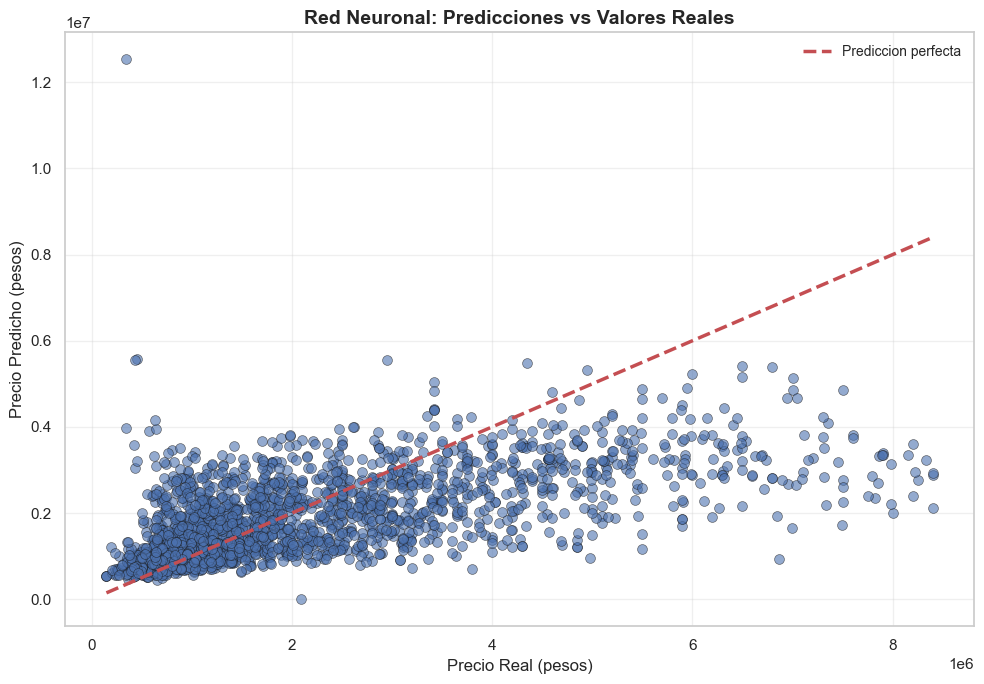

In [11]:
# Visualizacion: predicciones vs valores reales
plt.figure(figsize=(10, 7))
plt.scatter(y_test_original, nn_pred, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', linewidth=2.5, label='Prediccion perfecta')
plt.xlabel('Precio Real (pesos)', fontsize=12)
plt.ylabel('Precio Predicho (pesos)', fontsize=12)
plt.title('Red Neuronal: Predicciones vs Valores Reales', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(visualizations_dir / '07_nn_predictions.png', dpi=300, bbox_inches='tight')
plt.show()


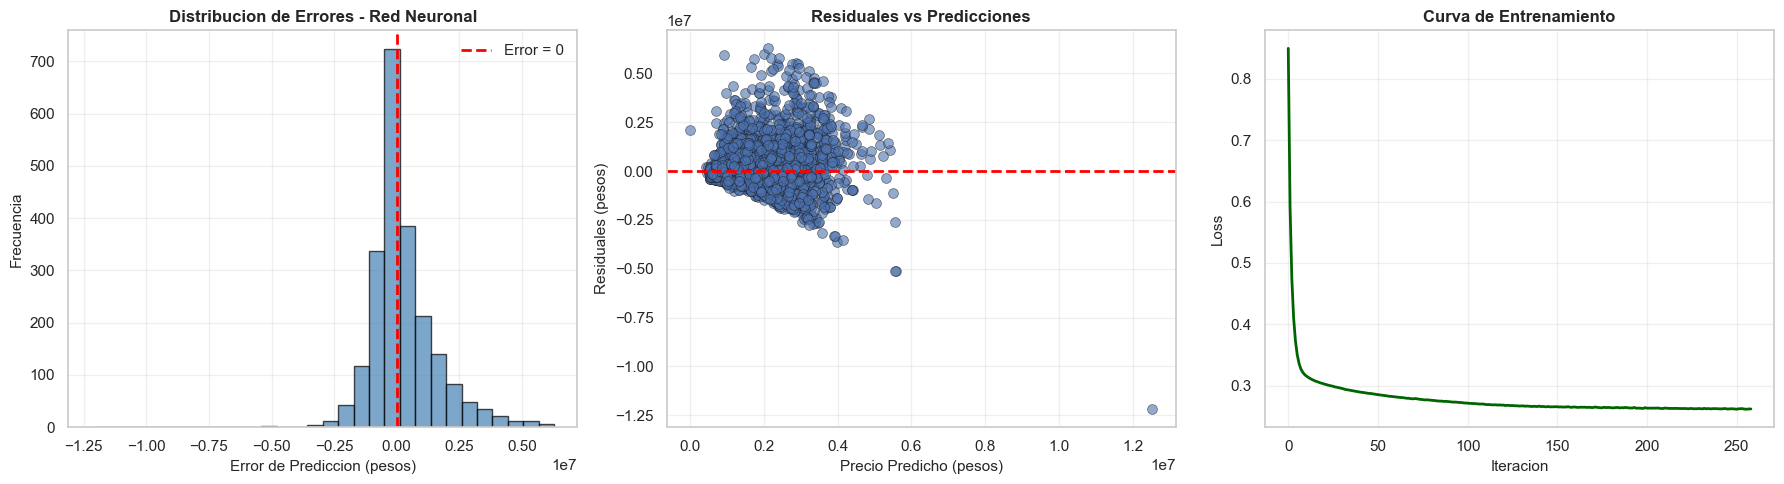

In [12]:
# Analisis de residuales y curva de perdida
nn_residuals = y_test_original - nn_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de residuales
axes[0].hist(nn_residuals, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
axes[0].set_xlabel('Error de Prediccion (pesos)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribucion de Errores - Red Neuronal', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuales vs predicciones
axes[1].scatter(nn_pred, nn_residuals, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Precio Predicho (pesos)', fontsize=11)
axes[1].set_ylabel('Residuales (pesos)', fontsize=11)
axes[1].set_title('Residuales vs Predicciones', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Curva de perdida
axes[2].plot(nn_model.loss_curve_, color='darkgreen', linewidth=2)
axes[2].set_xlabel('Iteracion', fontsize=11)
axes[2].set_ylabel('Loss', fontsize=11)
axes[2].set_title('Curva de Entrenamiento', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(visualizations_dir / '08_nn_residuals_loss.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Optimizacion de Hiperparametros con Grid Search


In [13]:
# Busqueda acotada de hiperparametros para mantener estabilidad numerica
print('Realizando Grid Search para optimizar hiperparametros...')
print('La busqueda se limita a arquitecturas y tasas de aprendizaje estables.')

param_grid = {
    'hidden_layer_sizes': [(16,), (64,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.01],
    'learning_rate_init': [0.001]
}

grid_search = GridSearchCV(
    MLPRegressor(
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=40,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1,
    error_score=np.nan
)

grid_search.fit(X_train_scaled, y_train_scaled)

print(f'\nMejores parametros: {grid_search.best_params_}')
print(f'Mejor puntuacion (R2 en validacion cruzada): {grid_search.best_score_:.4f}')


Realizando Grid Search para optimizar hiperparametros...
La busqueda se limita a arquitecturas y tasas de aprendizaje estables.



Mejores parametros: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
Mejor puntuacion (R2 en validacion cruzada): 0.4920


In [14]:
# Evaluar el modelo optimizado
best_nn_model = grid_search.best_estimator_
best_nn_pred_log_scaled = best_nn_model.predict(X_test_scaled)
best_nn_pred_log = y_scaler.inverse_transform(best_nn_pred_log_scaled.reshape(-1, 1)).ravel()
best_nn_pred = np.expm1(best_nn_pred_log)

best_nn_mae = mean_absolute_error(y_test_original, best_nn_pred)
best_nn_mse = mean_squared_error(y_test_original, best_nn_pred)
best_nn_rmse = np.sqrt(best_nn_mse)
best_nn_r2 = r2_score(y_test_original, best_nn_pred)

print('\n' + '=' * 50)
print('RESULTADOS DE LA RED NEURONAL OPTIMIZADA')
print('=' * 50)
print(f'R2 Score: {best_nn_r2:.4f}')
print(f'MAE: ${best_nn_mae:,.2f}')
print(f'RMSE: ${best_nn_rmse:,.2f}')
print('=' * 50)

improvement = ((best_nn_r2 - nn_r2) / abs(nn_r2)) * 100 if nn_r2 != 0 else np.nan
print(f'\nMejora en R2 sobre el conjunto de prueba: {improvement:+.2f}%')



RESULTADOS DE LA RED NEURONAL OPTIMIZADA
R2 Score: 0.3837
MAE: $891,235.22
RMSE: $1,326,889.48

Mejora en R2 sobre el conjunto de prueba: +8.59%


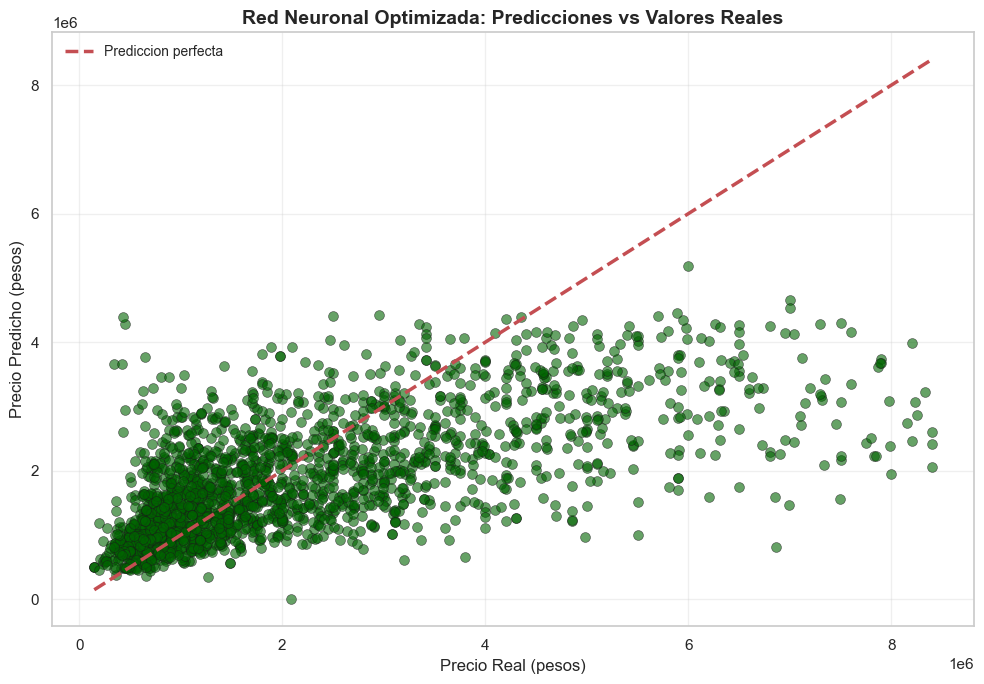

In [15]:
# Visualizacion del modelo optimizado
plt.figure(figsize=(10, 7))
plt.scatter(y_test_original, best_nn_pred, alpha=0.6, s=50, color='darkgreen', edgecolors='k', linewidth=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', linewidth=2.5, label='Prediccion perfecta')
plt.xlabel('Precio Real (pesos)', fontsize=12)
plt.ylabel('Precio Predicho (pesos)', fontsize=12)
plt.title('Red Neuronal Optimizada: Predicciones vs Valores Reales', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(visualizations_dir / '09_nn_optimized_predictions.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Comparacion con KNN

Se entrena un modelo `KNeighborsRegressor` con el mismo conjunto de entrenamiento/prueba para contrastar el desempeno de la red neuronal optimizada frente a un modelo basado en vecinos cercanos.


In [16]:
# Entrenamiento y evaluacion de KNN para comparar contra la red neuronal
print('Entrenando modelo KNN para la comparacion...')

y_train_original = np.expm1(y_train)

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn_grid_search = GridSearchCV(
    KNeighborsRegressor(),
    knn_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1
)

knn_grid_search.fit(X_train_scaled, y_train_original)
best_knn_model = knn_grid_search.best_estimator_
best_knn_pred = best_knn_model.predict(X_test_scaled)

knn_mae = mean_absolute_error(y_test_original, best_knn_pred)
knn_mse = mean_squared_error(y_test_original, best_knn_pred)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test_original, best_knn_pred)

print(f'Mejores parametros de KNN: {knn_grid_search.best_params_}')
print(f'Mejor score CV (R2): {knn_grid_search.best_score_:.4f}')
print(f'R2 en prueba: {knn_r2:.4f}')
print(f'MAE en prueba: ${knn_mae:,.2f}')
print(f'RMSE en prueba: ${knn_rmse:,.2f}')


Entrenando modelo KNN para la comparacion...


Mejores parametros de KNN: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Mejor score CV (R2): 0.5572
R2 en prueba: 0.5656
MAE en prueba: $697,844.77
RMSE en prueba: $1,113,934.35


In [17]:
# Tabla comparativa de metricas entre la red neuronal y KNN
comparison_df = pd.DataFrame({
    'Modelo': ['Red Neuronal Optimizada', 'KNN Optimizado'],
    'R2 Score': [best_nn_r2, knn_r2],
    'MAE': [best_nn_mae, knn_mae],
    'RMSE': [best_nn_rmse, knn_rmse],
})

comparison_df[['R2 Score', 'MAE', 'RMSE']] = comparison_df[['R2 Score', 'MAE', 'RMSE']].round(2)
print('\nTabla comparativa de metricas:')
print(comparison_df.to_string(index=False))
comparison_df



Tabla comparativa de metricas:
                 Modelo  R2 Score       MAE       RMSE
Red Neuronal Optimizada      0.38 891235.22 1326889.48
         KNN Optimizado      0.57 697844.77 1113934.35


,Modelo,R2 Score,MAE,RMSE
0,Red Neuronal Optimizada,0.38,891235.22,1326889.48
1,KNN Optimizado,0.57,697844.77,1113934.35


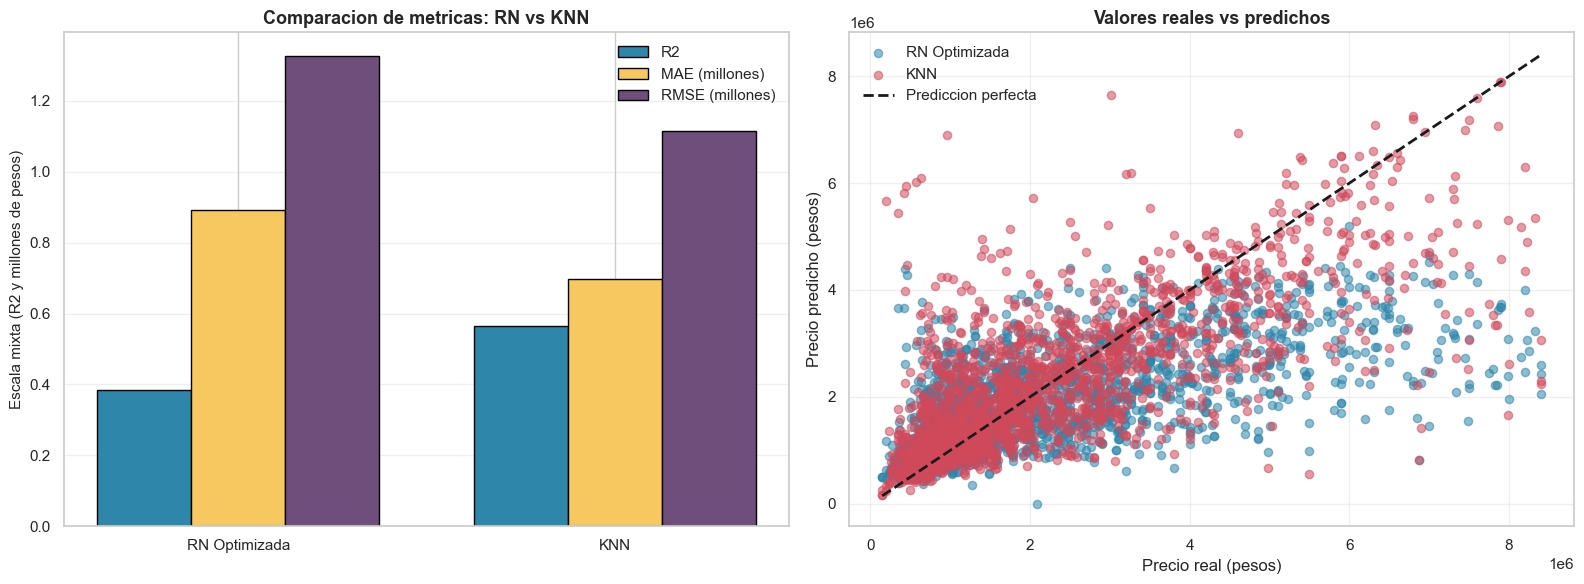

In [18]:
# Evidencia grafica: comparacion de metricas y dispersion de predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = ['RN Optimizada', 'KNN']
x = np.arange(len(models))
width = 0.25

axes[0].bar(x - width, [best_nn_r2, knn_r2], width, label='R2', color='#2E86AB', edgecolor='black')
axes[0].bar(x, [best_nn_mae / 1_000_000, knn_mae / 1_000_000], width, label='MAE (millones)', color='#F6C85F', edgecolor='black')
axes[0].bar(x + width, [best_nn_rmse / 1_000_000, knn_rmse / 1_000_000], width, label='RMSE (millones)', color='#6F4E7C', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title('Comparacion de metricas: RN vs KNN', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Escala mixta (R2 y millones de pesos)', fontsize=11)
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].scatter(y_test_original, best_nn_pred, alpha=0.55, s=35, label='RN Optimizada', color='#2E86AB')
axes[1].scatter(y_test_original, best_knn_pred, alpha=0.55, s=35, label='KNN', color='#D1495B')
axes[1].plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'k--', linewidth=2, label='Prediccion perfecta')
axes[1].set_title('Valores reales vs predichos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Precio real (pesos)')
axes[1].set_ylabel('Precio predicho (pesos)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(visualizations_dir / '11_nn_vs_knn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
# Conclusiones con evidencias tecnicas y recomendacion
from IPython.display import Markdown, display

best_model = 'Red Neuronal Optimizada' if best_nn_r2 >= knn_r2 else 'KNN Optimizado'
r2_diff = best_nn_r2 - knn_r2
mae_diff = knn_mae - best_nn_mae
rmse_diff = knn_rmse - best_nn_rmse

if best_model == 'Red Neuronal Optimizada':
    recommendation = (
        f"Se recomienda usar la **red neuronal optimizada** para este caso, porque logra el mejor ajuste global "
        f"(R2 = {best_nn_r2:.4f}) y reduce el error frente a KNN en aproximadamente "
        f"${mae_diff:,.0f} de MAE y ${rmse_diff:,.0f} de RMSE."
    )
else:
    recommendation = (
        f"Se recomienda usar **KNN optimizado** para este caso, porque obtiene un mejor ajuste global "
        f"(R2 = {knn_r2:.4f}) y deja errores menores que la red neuronal."
    )

conclusion_md = f'''
## 7. Conclusion y recomendacion final

### Evidencias tecnicas
- **Evidencia 1 (tabla de metricas):** la red neuronal optimizada obtuvo **R2 = {best_nn_r2:.4f}**, **MAE = ${best_nn_mae:,.0f}** y **RMSE = ${best_nn_rmse:,.0f}**, mientras que KNN obtuvo **R2 = {knn_r2:.4f}**, **MAE = ${knn_mae:,.0f}** y **RMSE = ${knn_rmse:,.0f}**.
- **Evidencia 2 (comparacion directa):** la diferencia de desempeno en **R2** fue de **{abs(r2_diff):.4f}** puntos y la diferencia de error absoluto medio fue de **${abs(mae_diff):,.0f}**.
- **Evidencia 3 (grafica):** en la dispersion de valores reales vs predichos, el modelo con mejor desempeno muestra una nube de puntos mas cercana a la diagonal de prediccion perfecta y menor dispersion en precios altos.

### Recomendacion
{recommendation}
'''

display(Markdown(conclusion_md))



## 7. Conclusion y recomendacion final

### Evidencias tecnicas
- **Evidencia 1 (tabla de metricas):** la red neuronal optimizada obtuvo **R2 = 0.3837**, **MAE = $891,235** y **RMSE = $1,326,889**, mientras que KNN obtuvo **R2 = 0.5656**, **MAE = $697,845** y **RMSE = $1,113,934**.
- **Evidencia 2 (comparacion directa):** la diferencia de desempeno en **R2** fue de **0.1820** puntos y la diferencia de error absoluto medio fue de **$193,390**.
- **Evidencia 3 (grafica):** en la dispersion de valores reales vs predichos, el modelo con mejor desempeno muestra una nube de puntos mas cercana a la diagonal de prediccion perfecta y menor dispersion en precios altos.

### Recomendacion
Se recomienda usar **KNN optimizado** para este caso, porque obtiene un mejor ajuste global (R2 = 0.5656) y deja errores menores que la red neuronal.
